# Sales Territory Analyis
## Northeast Region: Massachusetts & Maryland
### Performing a comparative sales analysis between two key retail territories. Focusing on identifying key, data-driven insights to help refine marketing strategies, optimize customer engagement, and boost product sales.

#### Importing necessary libraries and data

In [279]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [280]:
customer_list = pd.read_csv('customer_list.csv', sep='|')
# Customer list is divided by pipes in singular cells rather than multiple cells causing identification problems for read_csv function.
# By using sep parameter we're able to tell read_csv that values are separated by pipes and therefore organizing our data better in python.


In [281]:
store_sales = pd.read_csv('StoreSales.csv')

In [282]:
prod_cat = pd.read_csv('ProductCategories.csv')

In [283]:
prods = pd.read_csv('Products.csv')

In [284]:
store_dets = pd.read_csv('StoreDetail.csv')

In [285]:
customer_list.info()
customer_list.head()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


In [286]:
prod_cat.info()
prod_cat.head()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [287]:
prods.info()
prods.head()

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [288]:
store_dets.info()
store_dets.head()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [289]:
store_sales.info()
store_sales.head()

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


## Core Marketing Analysis

#### Who are the territory managers for the sales territories assigned? What are the store IDs and cities for the stores in each assigned sales territory?

The territory managers are Shruti Reddy (Maryland) and Bo Heap (Massachusetts). The store IDs and associated cities are located in the table below.

In [290]:
# We are working with Massachusetts and Maryland in the Northeast region
# We use those states to filter our table and acquire our territory managers then cast the list into a set to remove duplicates
territory_managers = set(store_dets[(store_dets['State'] == 'Maryland') | (store_dets['State'] == 'Massachusetts')]['Territory Manager'])

store_ids = list(store_dets.loc[store_dets['Territory Manager'].isin(territory_managers), 'Store ID'])
# cities = list(store_dets.loc[store_dets['Territory Manager'].isin(territory_managers), 'Store Location'])

# Answering the question directly with a table
store_dets_cleaned = store_dets[store_dets['State'].isin(['Maryland', 'Massachusetts'])]
store_dets_cleaned.drop(['Region Director' , 'Region'], axis=1, inplace=True)

store_dets_cleaned

,Store Location,State,Store ID,Territory Manager
43,Annapolis,Maryland,731,Shruti Reddy
44,Back River,Maryland,732,Shruti Reddy
45,Baltimore,Maryland,733,Shruti Reddy
46,Germantown,Maryland,734,Shruti Reddy
47,Howard,Maryland,735,Shruti Reddy
48,North Harford,Maryland,736,Shruti Reddy
49,Parkville,Maryland,737,Shruti Reddy
50,Queen Anne's County,Maryland,738,Shruti Reddy
51,Ridgely,Maryland,739,Shruti Reddy
52,Boston,Massachusetts,730,Bo Heap


#### What is monthly total revenue for in-store sales in each of the two sales territories, over the full period covered by the data?

##### Massachusetts Territory:

In [291]:
# Clean store sales data to only include our stores
store_sales_cleaned = store_sales[store_sales['Store ID'].isin(store_ids)]

#merge store sales data with store details on store IDs
merged_store_data = pd.merge(store_sales_cleaned, store_dets_cleaned, on='Store ID')

# Convert Transaction Date column first from str to date time object
merged_store_data['Transaction Date'] = pd.to_datetime(merged_store_data['Transaction Date'])

#Sorting by date and store number now to have correct chronological order as group by sorting does an awkard formatting '01-2023, 01-2024, ..., 02-2023)
merged_store_data = merged_store_data.sort_values(by=['Store ID', 'Transaction Date'])

# Group by Store ID and Transaction Date to get monthly revenue of each store
## Formatting Transaction date into month-year format using pandas built in function
### Sum function consolidates sales into a monthly value
#### Reset index returns output into table format for better readability
msd_monthly = merged_store_data.groupby(['Store ID', 'State', 'Store Location', merged_store_data['Transaction Date'].dt.strftime('%m - %Y')], sort=False)['Sale Amount'].sum().reset_index()

msd_monthly[msd_monthly['State'] == 'Massachusetts']

,Store ID,State,Store Location,Transaction Date,Sale Amount
0,730,Massachusetts,Boston,01 - 2022,3579.10
1,730,Massachusetts,Boston,02 - 2022,2602.11
2,730,Massachusetts,Boston,03 - 2022,3377.14
3,730,Massachusetts,Boston,04 - 2022,1609.82
4,730,Massachusetts,Boston,05 - 2022,4706.62
...,...,...,...,...,...
1291,817,Massachusetts,Worcester,08 - 2025,17532.86
1292,817,Massachusetts,Worcester,09 - 2025,19274.79
1293,817,Massachusetts,Worcester,10 - 2025,27724.93
1294,817,Massachusetts,Worcester,11 - 2025,16052.01


##### Maryland Territory:

In [292]:
msd_monthly[msd_monthly['State'] == 'Maryland']

,Store ID,State,Store Location,Transaction Date,Sale Amount
48,731,Maryland,Annapolis,01 - 2022,3924.44
49,731,Maryland,Annapolis,02 - 2022,2286.22
50,731,Maryland,Annapolis,03 - 2022,4491.44
51,731,Maryland,Annapolis,04 - 2022,3643.35
52,731,Maryland,Annapolis,05 - 2022,3823.11
...,...,...,...,...,...
475,739,Maryland,Ridgely,08 - 2025,11767.46
476,739,Maryland,Ridgely,09 - 2025,7745.50
477,739,Maryland,Ridgely,10 - 2025,12174.90
478,739,Maryland,Ridgely,11 - 2025,11507.25


#### How would you rank the sales performance of each store in each sales territory? Which are the top-performing stores?

##### Massachusetts Territory:

For ranking by sales performance, we only have to see which store has made the most amount in sales out of the territory.\
This does not mean they are top-performing stores.

In [293]:
# First we split stores by their sales territories
ma_alltime = merged_store_data[merged_store_data['State'] == 'Massachusetts']

# Group by year and Store ID
ma_alltime = ma_alltime.groupby(['Store ID', 'Store Location'])['Sale Amount'].sum().reset_index()

#Sorting from largest sales (contribution) to smallest
ma_alltime = ma_alltime.sort_values(by=['Sale Amount'], ascending=False)

# Creating rank column
ma_alltime['rank'] = ma_alltime['Sale Amount'].rank(ascending=False)

ma_alltime

,Store ID,Store Location,Sale Amount,rank
17,817,Worcester,602183.44,1.0
7,807,Leominster,338009.10,2.0
10,810,Nantucket,335547.81,3.0
14,814,Provincetown,328860.51,4.0
12,812,Northampton,322039.24,5.0
6,806,Holyoke,320516.53,6.0
16,816,Somerville,312873.59,7.0
4,804,Haverhill,305762.60,8.0
9,809,Lynn,302049.65,9.0
13,813,Pittsfield,301281.50,10.0


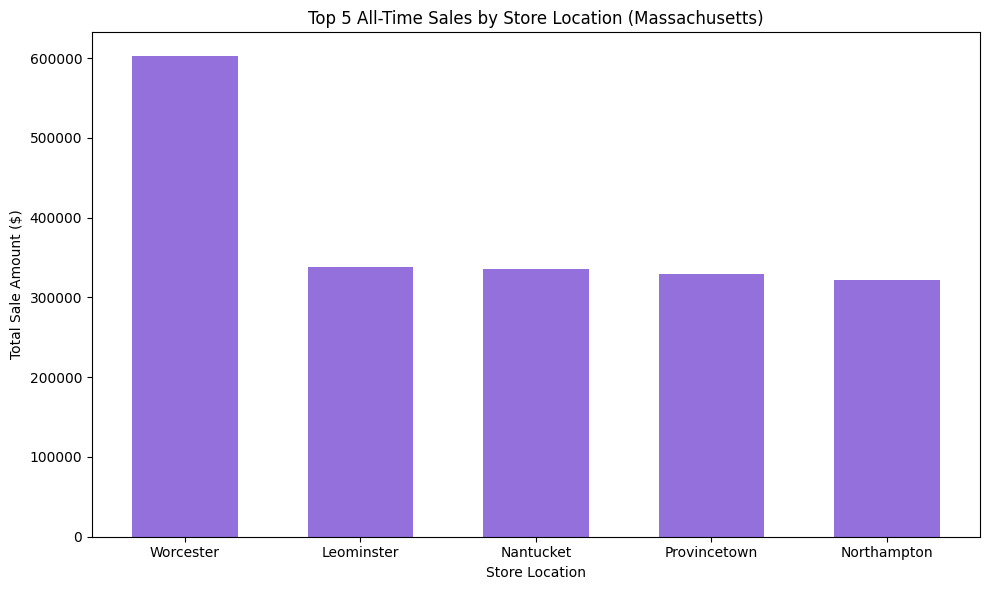

In [294]:
# Getting top 5
top_5_ma = ma_alltime.head()

# Setting size
plt.figure(figsize=(10, 6))

plt.bar(top_5_ma['Store Location'], top_5_ma['Sale Amount'], color='mediumpurple', width=0.6)
plt.title('Top 5 All-Time Sales by Store Location (Massachusetts)')
plt.xlabel('Store Location')
plt.ylabel('Total Sale Amount ($)')
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

##### Maryland Territory:

In [295]:
# For ranking by sales performance, we only have to see which store has made the most amount in sales out of the territory
## This does not mean they are top-performing stores

# First we split stores by their sales territories
md_alltime = merged_store_data[merged_store_data['State'] == 'Maryland']

# Group by year and Store ID
md_alltime = md_alltime.groupby(['Store ID', 'Store Location'])['Sale Amount'].sum().reset_index()

#Sorting from largest sales (contribution) to smallest
md_alltime = md_alltime.sort_values(by=['Sale Amount'], ascending=False)

# Creating rank column
md_alltime['rank'] = md_alltime['Sale Amount'].rank(ascending=False)

md_alltime



,Store ID,Store Location,Sale Amount,rank
5,736,North Harford,8708119.00,1.0
3,734,Germantown,584675.92,2.0
6,737,Parkville,320441.24,3.0
4,735,Howard,319394.58,4.0
8,739,Ridgely,318511.04,5.0
2,733,Baltimore,310099.90,6.0
1,732,Back River,303433.61,7.0
7,738,Queen Anne's County,298074.49,8.0
0,731,Annapolis,288865.31,9.0


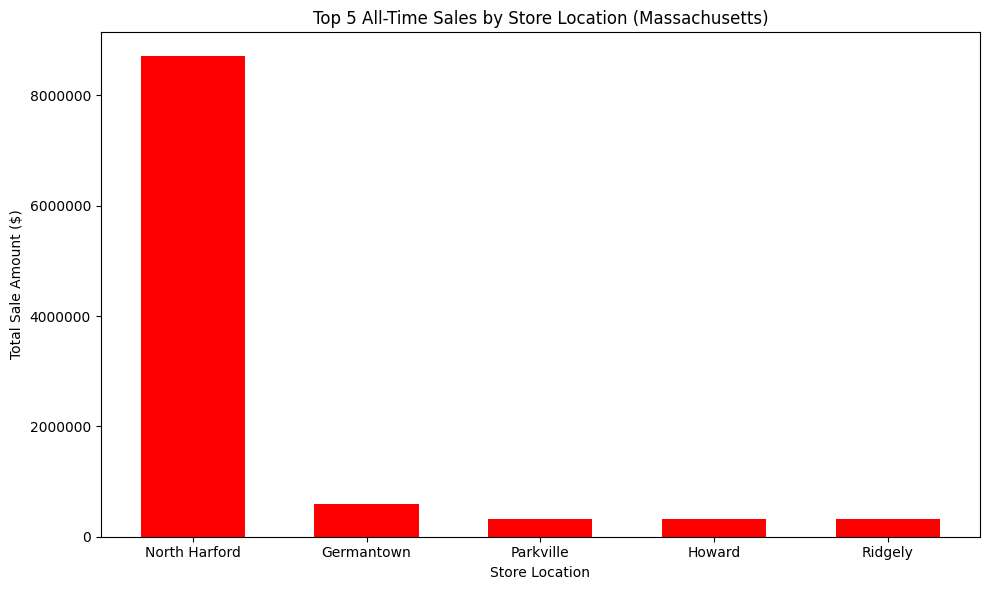

In [296]:
# Getting top 5
top_5_ma = md_alltime.head()

# Setting size
plt.figure(figsize=(10, 6))

plt.bar(top_5_ma['Store Location'], top_5_ma['Sale Amount'], color='red', width=0.6)
plt.title('Top 5 All-Time Sales by Store Location (Massachusetts)')
plt.xlabel('Store Location')
plt.ylabel('Total Sale Amount ($)')
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

##### Top-Performing Stores:

We can see the top stores per territory above. Below we see the top stores from both territories.

In [297]:
# Top-performing stores out of both territories

msd_alltime = merged_store_data

# We get the total revenue of their territories
msd_total_rev = msd_alltime['Sale Amount'].sum()

# Group by year and Store ID
msd_alltime = msd_alltime.groupby(['Store ID', 'State'])['Sale Amount'].sum().reset_index()

# Create a new column that includes it's contribution ratio of that year
msd_alltime['Contribution Ratio'] = msd_alltime['Sale Amount'] / msd_total_rev
msd_alltime['Contribution Ratio'] = [f"{ratio:.2%}" for ratio in msd_alltime['Contribution Ratio']]

# Adding total territory revenue for reference
msd_alltime['Total Territories Revenue'] = msd_total_rev

# Sorting by Sale Amount (contribution ratio)
msd_alltime.sort_values(by=['Sale Amount'], ascending=False, inplace=True)
msd_alltime.set_index('Store ID', inplace=True)
msd_alltime.head()


,State,Sale Amount,Contribution Ratio,Total Territories Revenue
Store ID,,,,
736,Maryland,8708119.00,50.67%,17184871.36
817,Massachusetts,602183.44,3.50%,17184871.36
734,Maryland,584675.92,3.40%,17184871.36
807,Massachusetts,338009.10,1.97%,17184871.36
810,Massachusetts,335547.81,1.95%,17184871.36


It is easy to call a store that has brought in the most revenue over the years a top-performing store but sometimes, all-time revenue does not tell us if the store has been stable or growing over the years. A store can over-perform one year and under-perform the others and that is not a top-performing store. Below we have a pivot table that includes all the stores that have had either continuous growth over the years or remained consistent with it's previous year and we have great news. They all have had continuous growth and/or consistency. Now that we know this, we can definitely consider our top revenue stores the top-performing stores!

In [298]:
# Originally had msd_alltime include years and when doing so, StoreID 736 was the top contributor with every year being more than the previous (consistent growth)
# Gave me the idea to loop through the table and pull the store ids of stores that appeared 4 times back to back HOWEVER the ordering was an issue
#   i.e there could be a store that shows up 4 times back to back but the ordering of the year could be 2023, 2025, 2022, 2024 which would not be consistent growth
#   but simply near consistent value like a cosine slope
# This lead to me learning about the pivot table and the ability to have years as columns and stores as rows and filter to only have stores that grew or maintained
# over the years

# Pivot Table
store_pivot = pd.pivot_table(merged_store_data, values='Sale Amount', index='Store ID', columns=merged_store_data['Transaction Date'].dt.year, aggfunc='sum').reset_index()
store_pivot.columns.name = None
store_pivot.set_index('Store ID', inplace=True)

consistent_growth_stores = store_pivot[
    (store_pivot[2025] >= store_pivot[2024]) & 
    (store_pivot[2024] >= store_pivot[2023]) & 
    (store_pivot[2023] >= store_pivot[2022])
]
# learned that every store has either grown or remained the same with every transition into the following year. no store has declined in sales.
consistent_growth_stores = consistent_growth_stores.sort_values([2025], ascending=False)
consistent_growth_stores.head()


,2022,2023,2024,2025
Store ID,,,,
736,1984274.30,2180188.06,2184992.51,2358664.13
734,103374.82,131981.52,132013.70,217305.88
817,98711.46,142741.05,144485.08,216245.85
733,48891.50,67854.91,68326.64,125026.85
730,36709.64,66757.66,67061.18,124672.81


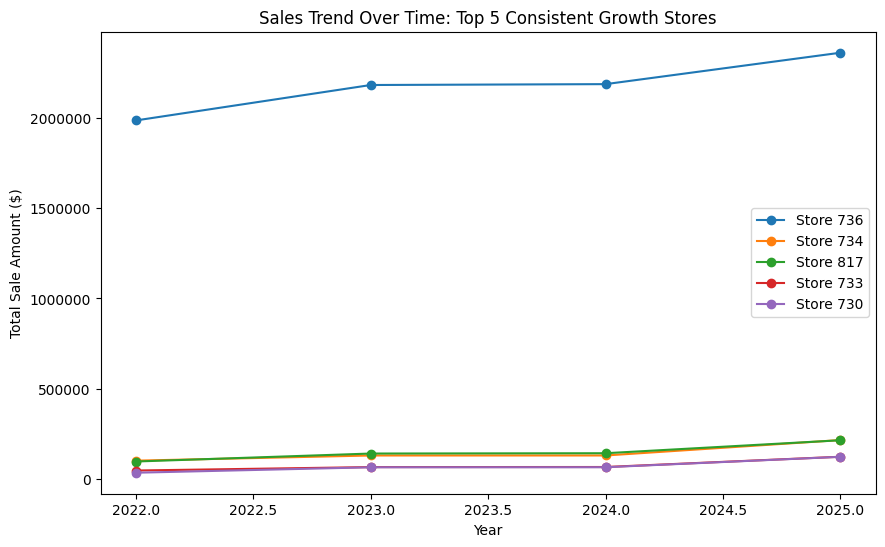

In [299]:
# Graphing top 5 2025 stores over the years
top_stores = consistent_growth_stores.head()

# x values
years = top_stores.columns

# Creating plot
plt.figure(figsize=(10, 6))
for store in top_stores.index:
    plt.plot(years, top_stores.loc[store], marker='o', label=f'Store {store}')

plt.title('Sales Trend Over Time: Top 5 Consistent Growth Stores')
plt.xlabel('Year')
plt.ylabel('Total Sale Amount ($)')
plt.legend()

# Correcting formatting for readability
plt.ticklabel_format(style='plain', axis='y')

plt.show()


#### Comparing the customer ID from the customer list data with the rewards ID from the sales data, who were the top customers in each sales territory?

##### Massachusetts Territory:

Our top customers in Massachusetts are Beverly Crusher, Tracy Jordan, Stanley H., Monica Geller, and Mellie Grant.

In [300]:
#merge store sales data with customer list data on rewards id
ma = merged_store_data[merged_store_data['State'] == 'Massachusetts']

merge_cust = lambda x: pd.merge(x, customer_list, left_on='RewardsID', right_on='cust_id')

merged_store_cust = merge_cust(ma)

merged_store_cust = merged_store_cust.groupby(['RewardsID', 'name', 'email', 'phone', 'cust_id'])['Sale Amount'].sum().reset_index()

merged_store_cust.sort_values(['Sale Amount'], ascending=False, inplace=True)
merged_store_cust

,RewardsID,name,email,phone,cust_id,Sale Amount
291,292.0,Beverly Crusher,crusher@enterprise.starfleet,1701-555-2207,292,4758.92
382,384.0,Tracy Jordan,tracy@tgs.nbc,212-555-1903,384,4197.55
46,47.0,Stanley H.,stanley@dundermifflin.com,570-555-5007,47,3979.73
2,3.0,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,3,3966.91
187,188.0,Mellie Grant,mellie@oliviapopeandassociates.com,202-555-1203,188,3948.41
...,...,...,...,...,...,...
387,389.0,Cerie,cerie@tgs.nbc,212-555-1908,389,70.35
288,289.0,Geordi La Forge,geordi@enterprise.starfleet,1701-555-2204,289,65.97
344,346.0,Cassie Howard,cassie@easthighland.high,626-555-1505,346,46.24
436,438.0,Estelle C.,estelle@vandelayindustries.com,212-555-2407,438,24.71


##### Maryland Territory:

Our top customers in Maryland are Cole Brown, Donna Hayward, Avon Barksdale, Trent Lane, and Magnitude.

In [301]:
#merge store sales data with customer list data on rewards id
md = merged_store_data[merged_store_data['State'] == 'Maryland']

merged_store_cust = merge_cust(md)

merged_store_cust = merged_store_cust.groupby(['RewardsID', 'name', 'email', 'phone', 'cust_id'])['Sale Amount'].sum().reset_index()

merged_store_cust.sort_values(['Sale Amount'], ascending=False, inplace=True)
merged_store_cust

,RewardsID,name,email,phone,cust_id,Sale Amount
179,180.0,Cole Brown,cole@wzhup.det,313-555-1105,180,7602.28
353,355.0,Donna Hayward,donna@twinpeaks.wa,206-555-1604,355,7081.17
465,467.0,Avon Barksdale,avon@westbaltimore.net,410-555-2706,467,6172.68
98,99.0,Trent Lane,trent@lawndale.high,973-555-9304,99,6076.89
74,75.0,Magnitude,pop@greendale.edu,303-555-9010,75,5916.81
...,...,...,...,...,...,...
356,358.0,James Hurley,james@twinpeaks.wa,206-555-1607,358,441.94
165,166.0,Earnest Marks,earn@paperboi.atl,404-555-1001,166,327.56
364,366.0,Uncle Fester,fester@nevermore.academy,914-555-1705,366,260.75
453,455.0,Gus Fring,gus@lospolloshermanos.biz,505-555-2604,455,248.56


#### What is the number of transactions per month by product category in each assigned territory? What is total sales revenue per month by category? What might this tell you about the most popular products, and where could there be opportunity for growth?

##### Massachusetts Territory:

Below we can see the number of transactions per month by product category and total sales revenue per month by category for Massachusetts. I also included the number of transactions by category and monthly sales by category which if needed can be used to see how much revenue that specific subcategory brings in regards to the monthly category revenue.

This data tells me that our most popular products in Massachusetts are Clothing items with it being 3 times in the top 5 number of transactions over different months. n see that in the tail end of our table, we have sculpting art supplies and humanities textbooks sales not performing too well in terms of number of transactions. This gives us an opportunity to run a promotion and drive sells upwards. Textbooks are a seasonal necessity, if we can bundle art supplies with it, we can recoup losses although we're not losing too much as these are products that do not have quick expiration dates.

In [302]:
# Merge product tables together (products and product categories)
prods_full = pd.merge(prods, prod_cat, on=['CategoryID', 'SubcategoryID'])

# Merge prods full with already merged sales table focused on MA territory ## Create lambda for reuse
merge_prods = lambda a: pd.merge(a, prods_full, on='Prod Num')
ma_prods = merge_prods(ma)

# Convert Transaction Date to datetime for formatting and sorting
ma_prods['Transaction Date'] = pd.to_datetime(ma_prods['Transaction Date'])
ma_prods.sort_values('Transaction Date', inplace=True)

# Group by category, transaction date (monthly), and add sales plus count sales
## This is so we can know our monthly category sales and monthly category transactions
ma_by_cat = ma_prods.groupby(['Category', ma_prods['Transaction Date'].dt.strftime('%m - %Y')])['Sale Amount'].aggregate(['sum', 'count']).reset_index()
ma_by_cat.rename(columns={'sum': 'Monthly Category Sales', 'count': 'Num. of Cat. Trans.'}, inplace=True)

# This is for our product categories (subcategories), their pricing and num of transactions
ma_prods_monthly = ma_prods.groupby(['Category', 'Subcategory', ma_prods['Transaction Date'].dt.strftime('%m - %Y')], sort=False)['Sale Amount'].aggregate(['sum', 'count']).reset_index()
ma_prods_monthly.rename(columns={'sum': 'Monthly Sales', 'count': 'Num. of Transactions'}, inplace=True)

ma_prods_monthly = pd.merge(ma_by_cat, ma_prods_monthly, on=['Category', 'Transaction Date'])
# Sort by num of transactions to find most popular product
ma_prods_monthly.sort_values('Num. of Transactions', ascending=False, inplace=True)

ma_prods_monthly

,Category,Transaction Date,Monthly Category Sales,Num. of Cat. Trans.,Subcategory,Monthly Sales,Num. of Transactions
157,Apparel and Merchandise,05 - 2025,13726.33,402,"Clothing (T-Shirts, Hoodies, and Jackets)",6815.80,124
1028,Books (General),10 - 2025,5688.88,192,Fiction,1861.50,93
1866,Technology & Accessories,10 - 2025,213921.34,455,Headphones,10549.88,91
124,Apparel and Merchandise,04 - 2025,12999.41,427,"Clothing (T-Shirts, Hoodies, and Jackets)",4953.76,89
317,Apparel and Merchandise,10 - 2025,11380.80,373,"Clothing (T-Shirts, Hoodies, and Jackets)",4861.28,87
...,...,...,...,...,...,...,...
957,Books (General),06 - 2022,999.59,38,Reference Materials,29.30,1
990,Books (General),08 - 2022,1245.44,46,Reference Materials,29.30,1
441,Art Supplies,02 - 2023,4819.78,142,Sculpting Supplies,26.52,1
411,Art Supplies,01 - 2024,5348.57,160,Sculpting Supplies,26.52,1


##### Maryland Territory:

Below we can see the number of transactions per month by product category and total sales revenue per month by category for Maryland. I also included the number of transactions by category and monthly sales by category which if needed can be used to see how much revenue that specific subcategory brings in regards to the monthly category revenue.

This data tells me that the most popular products are books, specifically the subcategories fiction and non-fiction as they lead in number of transactions over various months. When we look at the tail end of our table, we see that textbooks are one of our lowest number of transactions regardless of the subcategory. As textbooks are an every year necessity for students and new versions do not release until every couple of years, we can use this as an opportunity to run promotions seasonally and boost our textbook sales and drive revenue upwards.

In [303]:
# Merge prods full with already merged sales table focused on MD territory
md_prods = merge_prods(md)

# Convert Transaction Date to datetime for formatting and sorting
md_prods['Transaction Date'] = pd.to_datetime(md_prods['Transaction Date'])
md_prods.sort_values('Transaction Date', inplace=True)

# Group by category, transaction date (monthly), and add sales plus count sales
## This is so we can know our monthly category sales and monthly category transactions
md_by_cat = md_prods.groupby(['Category', md_prods['Transaction Date'].dt.strftime('%m - %Y')])['Sale Amount'].aggregate(['sum', 'count']).reset_index()
md_by_cat.rename(columns={'sum': 'Monthly Category Sales', 'count': 'Num. of Cat. Trans.'}, inplace=True)

# This is for our product categories (subcategories), their pricing and num of transactions
md_prods_monthly = md_prods.groupby(['Category', 'Subcategory', md_prods['Transaction Date'].dt.strftime('%m - %Y')], sort=False)['Sale Amount'].aggregate(['sum', 'count']).reset_index()
md_prods_monthly.rename(columns={'sum': 'Monthly Sales', 'count': 'Num. of Transactions'}, inplace=True)

md_prods_monthly = pd.merge(md_by_cat, md_prods_monthly, on=['Category', 'Transaction Date'])
# Sort by num of transactions to find most popular product
md_prods_monthly.sort_values('Num. of Transactions', ascending=False, inplace=True)

md_prods_monthly

,Category,Transaction Date,Monthly Category Sales,Num. of Cat. Trans.,Subcategory,Monthly Sales,Num. of Transactions
894,Books (General),01 - 2025,15453.87,460,Non-Fiction,3898.40,184
958,Books (General),05 - 2025,14241.97,456,Non-Fiction,3750.76,175
959,Books (General),05 - 2025,14241.97,456,Fiction,3618.75,161
928,Books (General),03 - 2025,15977.18,451,Fiction,3580.75,160
943,Books (General),04 - 2025,13835.45,415,Non-Fiction,3374.30,158
...,...,...,...,...,...,...,...
2416,Textbooks,12 - 2024,34297.45,203,Miscellaneous Academic Topics,456.60,2
1959,Textbooks,01 - 2023,34297.45,203,Miscellaneous Academic Topics,456.60,2
2178,Textbooks,06 - 2025,35969.92,212,Science,438.60,2
2002,Textbooks,02 - 2024,32194.16,189,Science,438.60,2


#### What is your recommendation for where to focus marketing attention in the next quarter?

We live in a world where we have good problems. Looking at our data, every store in our territories has either performed better than its previous year or, has remained consistent with the previous year. Not one store dropped in quality (sales). So we direct our attention to our products. We cannot promote products that are already popular; Products that are selling hot! By doing so, we're doing ourself a disservice and losing profit. When looking at the tail end of both our territories, we have products that are not high in number of transactions but still return a lot in revenue (textbooks). These products do not have a quick expiration date however we want to sell them as soon as possible, that is why our focus should be in bundling our low selling products (text books and art supplies) to make them more enticing and run seasonal promotions when school semesters begin. We also have a rewards system. This should be another thing to focus marketing on because when we let people know that they can be rewarded for purchasing things they already need, we give them another reason to come to us rather than competitors.